# Experimental setup

Set up for the experiment. This will load in the required packages, load in the data set, and load in the model. Then the experiment is run on the data set, saving the model weights and the results so they can be reloaded later. Below are the returned metrics.

## Metrics

- Overall performance in learned tasks: Usually average accuracy and average incremental accuracy, and confusion matrix
- Memory stability of old classes: uses forgetting measure (average forgetting of old tasks) and backward transfer (average influence of learning the k-th task on all old tasks)
- Learning plasticity of new classes: intransience measure (inability to learn a new task) and forward transfer (average influence of all old tasks on the current task)
- Resource (storage) and computational overheads (big O complexity), RAM usage.
- Discrepancy of task distribution

In [ ]:
#TODO:
# change batch testing to work with the continual metrics so that the R matrix is still correct.

## Imports

In [2]:
# Load packages
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision.transforms import transforms


import numpy as np
import matplotlib.pyplot as plt

import os
import time

from collections import defaultdict

print(torch.__version__)
print(torch.cuda.is_available())
torch.set_default_device('cuda')

2.10.0+cu128
True


In [ ]:
# Parameters

LOAD_FROM_FILE = False
FILE_LOAD_PATH = os.path.join(os.getcwd(), 'models', 'model_weights.pth')

TEST_INTERVAL = 'class' # Can be 'class', 'batch', or None. 
TEST_EVERY_N = 100 # Number of batches between tests, only used if TEST_INTERVAL='batch'


# Whether to compute measures that require training a separate reference/joint model
# (intranscience measure and forward transfer). Training a joint reference can be
# expensive; set to True only when you want the extra baselines computed.
COMPUTE_REFERENCE_BASELINES = True


REFERENCE_TRAIN_EPOCHS = 1  # epochs to train the joint/reference model when enabled
REFERENCE_BATCH_SIZE = 64   # batch size used for joint/reference training

In [4]:
# Check for necessary output folders

folder_path = os.path.join(os.getcwd(), 'datasets')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'models')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'results')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Load dataset and model
dataset_path = os.path.join(os.getcwd(), 'datasets')

download = not (os.path.exists(dataset_path))

print('Downloading dataset:',download)

print('Dataset path:', dataset_path)

# Define the desired size for the input tensors
desired_size = (224, 224)

# Create a transformation to resize the input tensors
resize_transform = transforms.Compose([
    transforms.Resize(desired_size),
    transforms.ToTensor()
])

dataset_train = torchvision.datasets.Imagenette(root = dataset_path, 
                                          split = 'train', 
                                          download = download, transform = resize_transform
                                          )

dataset_test = torchvision.datasets.Imagenette(root = dataset_path, 
                                          split = 'val', 
                                          download = download, transform = resize_transform
                                          )

def group_indices_by_class(dataset):
    class_to_indices = defaultdict(list)
    for idx in range(len(dataset)):
        _, y = dataset[idx]
        class_to_indices[int(y)].append(idx)
    return class_to_indices

class ContinualClassStream(torch.utils.data.IterableDataset):
    def __init__(self, dataset, class_order, class_to_indices):
        self.dataset = dataset
        self.class_order = class_order
        self.class_to_indices = class_to_indices

    def __iter__(self):
        for cls in self.class_order:
            for idx in self.class_to_indices[cls]:
                yield self.dataset[idx]

class_to_indices_train = group_indices_by_class(dataset_train)
class_order_train = sorted(class_to_indices_train.keys())  # or any order you want

train_stream = ContinualClassStream(dataset_train, class_order_train, class_to_indices_train)

train_dataloader = DataLoader(
    train_stream,
    batch_size=1,
    num_workers=0  # IMPORTANT for online streams
)

class_to_indices_test = group_indices_by_class(dataset_test)
class_order_test = sorted(class_to_indices_test.keys())  # or any order you want

test_stream = ContinualClassStream(dataset_test, class_order_test, class_to_indices_test)
test_dataloader = DataLoader(
    test_stream,
    batch_size=1,
    num_workers=0  # IMPORTANT for online streams
)

model = torchvision.models.convnext_tiny()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Using {device} device")
print(model)


Dataset path: c:\Users\naido\Documents\ChalmersCourses\Thesis\continous-MoE\datasets
Using cuda device
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()

In [ ]:
# Create training metaparameters

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

epochs = 1 # required for continual online learning to be 1

In [ ]:
# Training fcns

def train(dataloader, model, loss_fn, optimizer, test_dataloader=None, test_fn=None, 
          test_interval='class', test_every_n=100, class_order=None):
    """
    Train on continual learning stream with per-class tracking and optional intermediate testing.
    
    Args:
        dataloader: DataLoader with ContinualClassStream
        model: Model to train
        loss_fn: Loss function
        optimizer: Optimizer
        test_dataloader: Optional DataLoader for testing between training phases
        test_fn: Test function to call (should be the test function)
        test_interval: 'class' (test after each class), 'batch' (test every N batches), or None (no intermediate testing)
        test_every_n: Number of batches between tests (only used if test_interval='batch')
        class_order: List of class labels in order (for per-class metrics)
    
    Returns:
        Dictionary with training metrics per class and test metrics history
    """
    model.train()
    batch_count = 0
    current_class = None
    class_batch_counts = defaultdict(int)
    class_losses = defaultdict(float)
    training_metrics = {}
    test_history = []  # Track test metrics over time
    class_change_steps = []  # Track batch indices where class changes
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_class = int(y[0].item())  # Get class label from batch
        
        # Track when we transition to a new class
        if current_class != y_class:
            if current_class is not None:
                avg_loss = class_losses[current_class] / class_batch_counts[current_class]
                training_metrics[current_class] = {
                    'samples': class_batch_counts[current_class],
                    'avg_loss': avg_loss
                }
                print(f"  Class {current_class} - Processed {class_batch_counts[current_class]} samples, Avg loss: {avg_loss:>7f}")
                
                # Test after each class if requested
                if test_interval == 'class' and test_dataloader is not None and test_fn is not None:
                    print(f"  Testing after Class {current_class}:")
                    test_result = test_fn(test_dataloader, model, loss_fn, class_order=class_order)
                    test_result['step'] = current_class  # Track which class we just trained
                    test_result['step_type'] = 'class'
                    test_history.append(test_result)
                    model.train()  # Return to training mode
            
            current_class = y_class
            print(f"Starting training on Class {current_class}")
            class_change_steps.append(batch)  # Mark the batch index where class changes

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        class_batch_counts[current_class] += 1
        class_losses[current_class] += loss.item()
        batch_count += 1

        if batch % 100 == 0 and batch > 0:
            print(f"  Batch {batch}: loss: {loss.item():>7f}")
            
            # Test every N batches if requested
            if test_interval == 'batch' and batch % test_every_n == 0 and test_dataloader is not None and test_fn is not None:
                print(f"  Testing at Batch {batch}:")
                test_result = test_fn(test_dataloader, model, loss_fn, class_order=class_order)
                test_result['step'] = batch  # Track which batch we're at
                test_result['step_type'] = 'batch'
                test_result['current_class'] = current_class
                test_history.append(test_result)
                model.train()  # Return to training mode
    
    # Print final class stats
    if current_class is not None:
        avg_loss = class_losses[current_class] / class_batch_counts[current_class]
        training_metrics[current_class] = {
            'samples': class_batch_counts[current_class],
            'avg_loss': avg_loss
        }
        print(f"  Class {current_class} - Processed {class_batch_counts[current_class]} samples, Avg loss: {avg_loss:>7f}")
        
        # Final test after last class if requested
        if test_interval == 'class' and test_dataloader is not None and test_fn is not None:
            print(f"  Testing after Class {current_class}:")
            test_result = test_fn(test_dataloader, model, loss_fn, class_order=class_order)
            test_result['step'] = current_class
            test_result['step_type'] = 'class'
            test_history.append(test_result)
            model.train()  # Return to training mode
    
    print(f"Training complete. Total batches: {batch_count}\n")
    return training_metrics, test_history, class_change_steps


def test(dataloader, model, loss_fn, class_order=None):
    """
    Test on continual learning stream with comprehensive continual learning metrics.
    
    Metrics computed (based on continual learning survey):
    - Per-class accuracy: Accuracy on each class
    - Overall accuracy: Average accuracy across all classes
    - Backward Transfer (BWT): Average change in previous task accuracy after learning new tasks
    - Forward Transfer (FWT): Average improvement on new tasks from learning previous tasks
    - Average Forgetting (AF): Average decrease in accuracy on old tasks
    
    Args:
        dataloader: DataLoader with ContinualClassStream
        model: Model to evaluate
        loss_fn: Loss function
        class_order: List of class labels in order (for per-class metrics)
    
    Returns:
        Dictionary with test metrics including per-class metrics, overall metrics, and continual learning metrics
    """
    model.eval()
    
    test_loss = 0.0
    correct = 0
    total = 0
    
    current_class = None
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    class_losses = defaultdict(float)
    class_batch_counts = defaultdict(int)
    confusion_matrix = {}  # Track predictions per class
    test_metrics = {}
    
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            y_class = int(y[0].item())  # Get class label from batch
            
            # Track when we transition to a new class
            if current_class != y_class:
                if current_class is not None:
                    class_acc = (100 * class_correct[current_class] / class_total[current_class])
                    class_avg_loss = class_losses[current_class] / class_batch_counts[current_class]
                    test_metrics[current_class] = {
                        'accuracy': class_acc,
                        'avg_loss': class_avg_loss,
                        'total_samples': class_total[current_class]
                    }
                    print(f"  Class {current_class} - Accuracy: {class_acc:>0.1f}%, Avg loss: {class_avg_loss:>8f}")
                current_class = y_class
                print(f"Testing on Class {current_class}")
            
            pred = model(X)
            loss = loss_fn(pred, y)
            
            test_loss += loss.item()
            total += y.size(0)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
            # Per-class tracking
            y_class_label = int(y[0].item())
            pred_class_label = int(pred.argmax(1)[0].item())
            class_total[y_class_label] += 1
            class_losses[y_class_label] += loss.item()
            class_batch_counts[y_class_label] += 1
            class_correct[y_class_label] += (pred.argmax(1) == y).type(torch.float).sum().item()
            
            # Build confusion matrix
            if y_class_label not in confusion_matrix:
                confusion_matrix[y_class_label] = defaultdict(int)
            confusion_matrix[y_class_label][pred_class_label] += 1
    
    # Print final class stats and compute per-class accuracies
    per_class_accuracies = {}
    if current_class is not None:
        class_acc = (100 * class_correct[current_class] / class_total[current_class])
        class_avg_loss = class_losses[current_class] / class_batch_counts[current_class]
        test_metrics[current_class] = {
            'accuracy': class_acc,
            'avg_loss': class_avg_loss,
            'total_samples': class_total[current_class]
        }
        print(f"  Class {current_class} - Accuracy: {class_acc:>0.1f}%, Avg loss: {class_avg_loss:>8f}")
    
    # Compile all per-class accuracies
    for cls in sorted(test_metrics.keys()):
        per_class_accuracies[cls] = test_metrics[cls]['accuracy']
    
    # Overall metrics
    avg_loss = test_loss / (batch + 1) if batch >= 0 else 0
    overall_accuracy = 100 * correct / total if total > 0 else 0
    average_task_accuracy = np.mean(list(per_class_accuracies.values())) if per_class_accuracies else 0
    
    test_metrics['overall'] = {
        'accuracy': overall_accuracy,
        'avg_loss': avg_loss,
        'total_samples': total,
        'average_task_accuracy': average_task_accuracy,
        'per_class_accuracies': per_class_accuracies,
        'confusion_matrix': dict(confusion_matrix)
    }
    
    print(f"\nTest Summary:")
    print(f"  Overall Accuracy: {overall_accuracy:>0.1f}%")
    print(f"  Average Task Accuracy: {average_task_accuracy:>0.1f}%")
    print(f"  Overall Avg Loss: {avg_loss:>8f}\n")
    
    return test_metrics


In [ ]:
# Training

# Option 1: Test after each class
if TEST_INTERVAL == 'class':
    train_metrics, test_history, class_change_steps = train(train_dataloader, model, loss_fn, optimizer, 
                        test_dataloader=test_dataloader, test_fn=test, 
                        test_interval='class')

# Option 2: Test every N batches

elif TEST_INTERVAL == 'batch':
    train_metrics, test_history, class_change_steps = train(train_dataloader, model, loss_fn, optimizer, 
                        test_dataloader=test_dataloader, test_fn=test, 
                        test_interval='batch', test_every_n=TEST_EVERY_N)

# Option 3: No intermediate testing

else:
    test_history = []
    class_change_steps = []
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_dataloader, model, loss_fn, optimizer)
        test_result = test(test_dataloader, model, loss_fn)
        test_result['step'] = t + 1
        test_result['step_type'] = 'epoch'
        test_history.append(test_result)

##################

print("Done!")

timestr = time.strftime("%Y%m%d-%H%M%S")

# save testing metrics

torch.save(test_history, os.path.join(os.getcwd(), 'results', timestr + 'train_metrics.pth'))

# save model weights

torch.save(model.state_dict(), os.path.join(os.getcwd(), 'models', timestr + 'model_weights.pth'))
print("Saved PyTorch Model State to " + timestr + "model_weights.pth")


Starting training on Class 0
  Batch 100: loss: 0.006117
  Batch 200: loss: 0.003283
  Batch 300: loss: 0.002257
  Batch 400: loss: 0.001738
  Batch 500: loss: 0.001682
  Batch 600: loss: 0.001152
  Batch 700: loss: 0.001014
  Batch 800: loss: 0.000869
  Batch 900: loss: 0.000985
  Class 0 - Processed 963 samples, Avg loss: 0.015749
  Testing after Class 0:
Testing on Class 0
  Class 0 - Accuracy: 100.0%, Avg loss: 0.000745
Testing on Class 1
  Class 1 - Accuracy: 0.0%, Avg loss: 14.896335
Testing on Class 2
  Class 2 - Accuracy: 0.0%, Avg loss: 14.516160
Testing on Class 3
  Class 3 - Accuracy: 0.0%, Avg loss: 13.864083
Testing on Class 4
  Class 4 - Accuracy: 0.0%, Avg loss: 13.850002
Testing on Class 5
  Class 5 - Accuracy: 0.0%, Avg loss: 14.889596
Testing on Class 6
  Class 6 - Accuracy: 0.0%, Avg loss: 14.831414
Testing on Class 7
  Class 7 - Accuracy: 0.0%, Avg loss: 13.941711
Testing on Class 8
  Class 8 - Accuracy: 0.0%, Avg loss: 14.492825
Testing on Class 9
  Class 9 - Accur

CONTINUAL LEARNING EVALUATION METRICS

1. FINAL PERFORMANCE METRICS
--------------------------------------------------------------------------------
Overall Accuracy: 9.94%
Average Task Accuracy: 10.00%
Overall Average Loss: 11.297471

Per-Class Accuracy:
  Class 0: 0.00%
  Class 1: 0.00%
  Class 2: 0.00%
  Class 3: 0.00%
  Class 4: 0.00%
  Class 5: 0.00%
  Class 6: 0.00%
  Class 7: 0.00%
  Class 8: 0.00%
  Class 9: 100.00%

2. CONTINUAL LEARNING METRICS (from Survey)
--------------------------------------------------------------------------------
Average Incremental Accuracy (AIA) - final step: 10.00%
Forgetting measure (FM): 90.00%
Backward Transfer (BWT): -90.00%

Computing per-class reference baselines (fresh model per class, single pass)...
  Trained ref model for class 0 (single pass), avg loss: 0.8978
  Trained ref model for class 1 (single pass), avg loss: 0.9988
  Trained ref model for class 2 (single pass), avg loss: 1.0956
  Trained ref model for class 3 (single pass), avg l

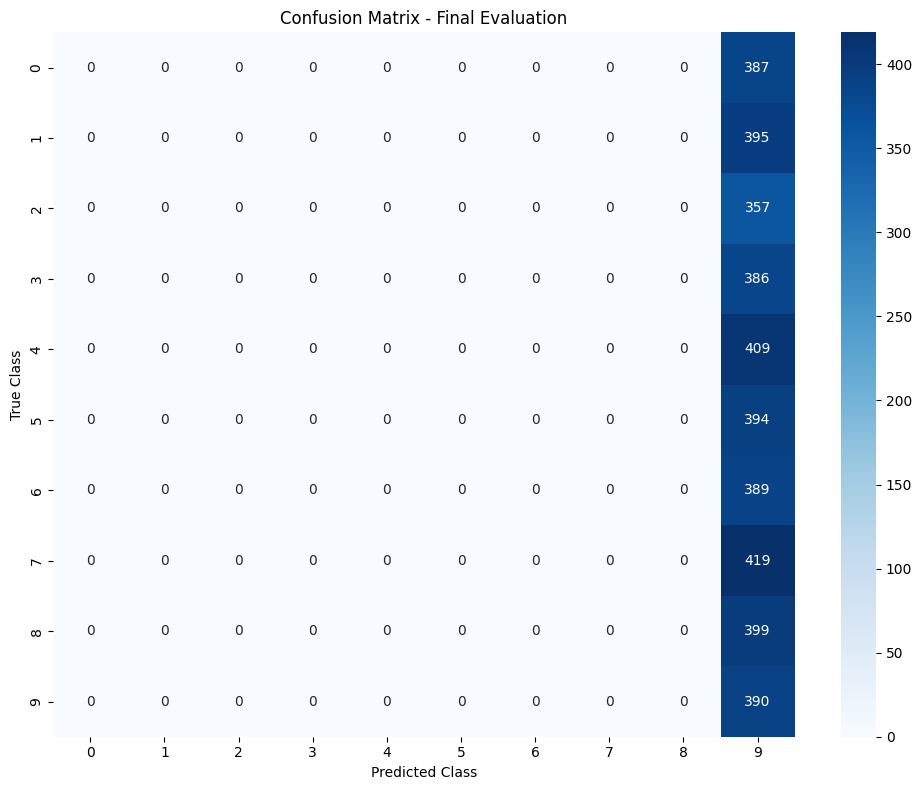


Confusion Matrix (rows: true class, columns: predicted class)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

4. METRICS OVER TIME
--------------------------------------------------------------------------------


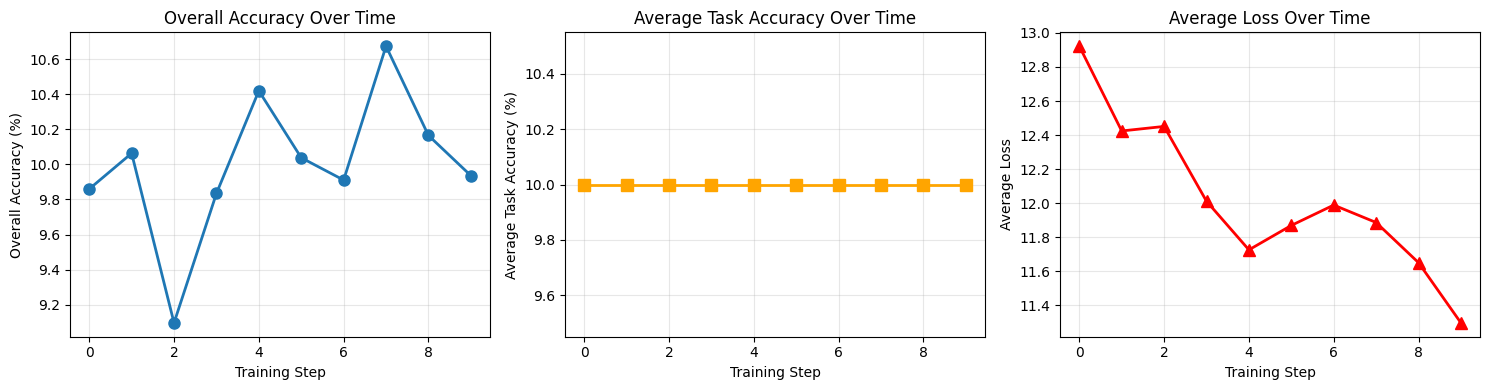

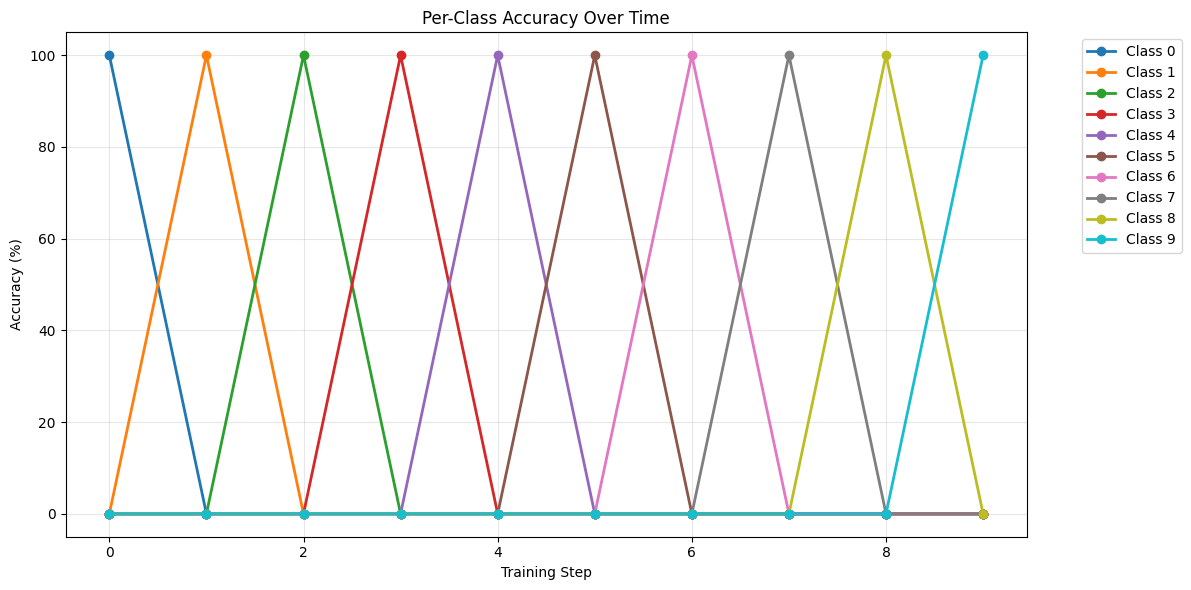

: 

In [ ]:
# Metrics and plots
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
import seaborn as sns

print("=" * 80)
print("CONTINUAL LEARNING EVALUATION METRICS")
print("=" * 80)

# --- Safe helpers ---------------------------------------------------------
def safe_get_per_class(test_result, cls):
    return test_result.get('overall', {}).get('per_class_accuracies', {}).get(cls, np.nan)

# Extract final test metrics (if available)
final_test_result = test_history[-1] if test_history else {}
final_overall = final_test_result.get('overall', {})
per_class_acc = final_overall.get('per_class_accuracies', {})
confusion_mat = final_overall.get('confusion_matrix', {})

print("\n1. FINAL PERFORMANCE METRICS")
print("-" * 80)
print(f"Overall Accuracy: {final_overall.get('accuracy', 0):>0.2f}%")
print(f"Average Task Accuracy: {final_overall.get('average_task_accuracy', 0):>0.2f}%")
print(f"Overall Average Loss: {final_overall.get('avg_loss', 0):>8f}")

print("\nPer-Class Accuracy:")
for cls in sorted(per_class_acc.keys()):
    print(f"  Class {cls}: {per_class_acc[cls]:>0.2f}%")

# -------------------------------------------------------------------------
# Build accuracy matrix R where R[k, j] is accuracy on task j after learning task k
# Rows: test steps (in order of test_history). Columns: class labels (sorted).
# Missing values are filled with np.nan so downstream calculations can ignore them.
# -------------------------------------------------------------------------
all_classes = sorted({
    cls for t in test_history for cls in t.get('overall', {}).get('per_class_accuracies', {}).keys()
}) if test_history else []

num_steps = len(test_history)
num_tasks = len(all_classes)

# For batch mode, mark class changes and still build R by class
if num_steps > 0 and num_tasks > 0:
    class_to_col = {c: i for i, c in enumerate(all_classes)}
    R = np.full((num_steps, num_tasks), np.nan)
    for step_idx, t in enumerate(test_history):
        for cls, acc in t.get('overall', {}).get('per_class_accuracies', {}).items():
            R[step_idx, class_to_col[cls]] = acc
else:
    R = np.empty((0, 0))

# 2. CONTINUAL-LEARNING METRICS (AIA, BWT, FM, IM, FWT)
print("\n2. CONTINUAL LEARNING METRICS (from Survey)")
print("-" * 80)

# Average Incremental Accuracy (AIA): for step k, average_j<=k R[k,j]
aia_per_step = []
if R.size:
    for k in range(R.shape[0]):
        row = R[k, :k+1]  # j <= k
        aia_per_step.append(np.nanmean(row))
    aia_final = aia_per_step[-1]
    print(f"Average Incremental Accuracy (AIA) - final step: {aia_final:>0.2f}%")
else:
    print("Average Incremental Accuracy (AIA): not available (no test history)")

# Backward Transfer (BWT) and Forgetting Measure (FM)
if R.size and R.shape[0] > 1:
    final_row = R[-1, :]
    diag = np.array([R[i, i] for i in range(min(R.shape[0], R.shape[1]))])

    # Only consider tasks up to the current task minus one
    max_task = min(R.shape[0], R.shape[1]) - 1  # up to T-2 if T tasks
    if max_task > 0:
        valid_idx = [i for i in range(max_task) if (not np.isnan(diag[i]) and not np.isnan(final_row[i]))]
        if valid_idx:
            forgetting_vals = [diag[i] - final_row[i] for i in valid_idx]
            fm = np.mean(forgetting_vals)
            # BWT as average (final - initially observed after task learning)
            bwt_vals = [final_row[i] - diag[i] for i in valid_idx]
            bwt = np.mean(bwt_vals)
            print(f"Forgetting measure (FM): {fm:>0.2f}%")
            print(f"Backward Transfer (BWT): {bwt:>0.2f}%")
        else:
            print("FM / BWT: insufficient per-task accuracies to compute")
    else:
        print("FM / BWT: not enough tasks to compute (need at least two tasks)")
else:
    print("FM / BWT: not available (need at least two test steps and per-class accuracies)")

# Optional: Intranscience Measure (IM) and Forward Transfer (FWT)
# These require a reference/joint baseline model (COMPUTE_REFERENCE_BASELINES flag).
if COMPUTE_REFERENCE_BASELINES:
    print("\nComputing per-class reference baselines (fresh model per class, single pass)...")

    # train a fresh model for each class using a single-pass (one epoch over that class'
    # training split) to match the continual learner's single-pass behaviour.
    gen_device = getattr(device, 'type', 'cpu')
    gen = torch.Generator(device=gen_device)

    per_class_acc = {}

    for cls in all_classes:
        indices = class_to_indices_train.get(cls, [])
        if not indices:
            per_class_acc[cls] = np.nan
            continue

        # Subset the training dataset to this class only
        class_train_subset = torch.utils.data.Subset(dataset_train, indices)
        class_train_loader = torch.utils.data.DataLoader(class_train_subset, batch_size=REFERENCE_BATCH_SIZE, shuffle=True, num_workers=0, generator=gen)

        # Fresh model for this class
        ref_model_c = torchvision.models.convnext_tiny()
        ref_model_c.to(device)
        ref_loss = nn.CrossEntropyLoss()
        ref_optimizer = torch.optim.SGD(ref_model_c.parameters(), lr=1e-3)

        # Single pass over the class training data (match continual single-pass)
        ref_model_c.train()
        epoch_loss = 0.0
        for X, y in class_train_loader:
            X, y = X.to(device), y.to(device)
            pred = ref_model_c(X)
            loss = ref_loss(pred, y)
            loss.backward()
            ref_optimizer.step()
            ref_optimizer.zero_grad()
            epoch_loss += loss.item()
        # optional: print per-class training summary
        print(f"  Trained ref model for class {cls} (single pass), avg loss: {epoch_loss/len(class_train_loader):.4f}")

        # Evaluate this fresh model on the test split of the same class
        test_indices = class_to_indices_test.get(cls, [])
        if not test_indices:
            per_class_acc[cls] = np.nan
            continue

        class_test_subset = torch.utils.data.Subset(dataset_test, test_indices)
        class_test_loader = torch.utils.data.DataLoader(class_test_subset, batch_size=REFERENCE_BATCH_SIZE, shuffle=False, num_workers=0, generator=gen)

        ref_model_c.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in class_test_loader:
                X, y = X.to(device), y.to(device)
                preds = ref_model_c(X)
                pred_labels = preds.argmax(1)
                correct += (pred_labels == y).sum().item()
                total += y.size(0)
        per_class_acc[cls] = 100.0 * correct / max(1, total)

    # Expose per-class reference accuracies under the same name used downstream
    joint_per_class_acc = {cls: per_class_acc.get(cls, np.nan) for cls in all_classes}

    # Save per-class reference results
    timestr_ref = time.strftime("%Y%m%d-%H%M%S")
    ref_save_path = os.path.join(os.getcwd(), 'results', timestr_ref + '_per_class_reference.pth')
    torch.save({'joint_per_class_acc': joint_per_class_acc}, ref_save_path)
    print(f"Saved per-class reference baselines to {ref_save_path} (model weights not saved)")
    # Intranscience (IM): joint_acc - continual_final_acc (average across tasks)
    im_list = []
    for idx, cls in enumerate(all_classes):
        joint_acc = joint_per_class_acc.get(cls, np.nan)
        cl_final_acc = R[-1, idx] if R.size and idx < R.shape[1] else np.nan
        if not np.isnan(joint_acc) and not np.isnan(cl_final_acc):
            im_list.append(joint_acc - cl_final_acc)
    if im_list:
        im = np.mean(im_list)
        print(f"Intranscience measure (IM): {im:>0.2f}%")
    else:
        print("Intranscience (IM): insufficient data to compute")

    # Forward Transfer (FWT): average over k>1 of (R[k-1,k] - joint_acc_k)
    fwt_list = []
    if R.size and R.shape[0] > 1:
        # class order in test_history rows matches 'all_classes' columns mapping
        for k in range(1, R.shape[0]):
            # current task column is the same index as row 'k' only if classes and steps align
            if k < R.shape[1]:
                prior_acc = R[k-1, k]
                baseline = joint_per_class_acc.get(all_classes[k], np.nan)
                if not np.isnan(prior_acc) and not np.isnan(baseline):
                    fwt_list.append(prior_acc - baseline)
    if fwt_list:
        fwt = np.mean(fwt_list)
        print(f"Forward Transfer (FWT): {fwt:>0.2f}%")
    else:
        print("Forward Transfer (FWT): insufficient data to compute")

else:
    print("\nIM / FWT disabled — set COMPUTE_REFERENCE_BASELINES = True at the top of the notebook to enable")


# Confusion Matrix Visualization
if confusion_mat:
    print("\n3. CONFUSION MATRIX")
    print("-" * 80)

    # Convert confusion matrix dict to numpy array
    all_classes_conf = sorted(set(
        list(confusion_mat.keys()) +
        [item for subdict in confusion_mat.values() for item in subdict.keys()]
    ))

    cm_array = np.zeros((len(all_classes_conf), len(all_classes_conf)))
    for true_cls in confusion_mat:
        for pred_cls in confusion_mat[true_cls]:
            true_idx = all_classes_conf.index(true_cls)
            pred_idx = all_classes_conf.index(pred_cls)
            cm_array[true_idx, pred_idx] = confusion_mat[true_cls][pred_cls]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues', 
                xticklabels=all_classes_conf, yticklabels=all_classes_conf)
    plt.title('Confusion Matrix - Final Evaluation')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()

    print("\nConfusion Matrix (rows: true class, columns: predicted class)")
    print(f"Classes: {all_classes_conf}")

# Metrics Over Time
if len(test_history) > 1:
    print("\n4. METRICS OVER TIME")
    print("-" * 80)

    overall_accs = [t.get('overall', {}).get('accuracy', 0) for t in test_history]
    avg_task_accs = [t.get('overall', {}).get('average_task_accuracy', 0) for t in test_history]
    avg_losses = [t.get('overall', {}).get('avg_loss', 0) for t in test_history]

    steps = [t.get('step', i) for i, t in enumerate(test_history)]

    # Plot metrics over time
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Overall Accuracy
    axes[0].plot(steps, overall_accs, marker='o', linewidth=2, markersize=8)
    axes[0].set_xlabel('Training Step')
    axes[0].set_ylabel('Overall Accuracy (%)')
    axes[0].set_title('Overall Accuracy Over Time')
    axes[0].grid(True, alpha=0.3)

    # Average Task Accuracy
    axes[1].plot(steps, avg_task_accs, marker='s', linewidth=2, markersize=8, color='orange')
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Average Task Accuracy (%)')
    axes[1].set_title('Average Task Accuracy Over Time')
    axes[1].grid(True, alpha=0.3)

    # Average Loss
    axes[2].plot(steps, avg_losses, marker='^', linewidth=2, markersize=8, color='red')
    axes[2].set_xlabel('Training Step')
    axes[2].set_ylabel('Average Loss')
    axes[2].set_title('Average Loss Over Time')
    axes[2].grid(True, alpha=0.3)

    # Mark class changes on all plots if in batch mode
    if TEST_INTERVAL == 'batch' and 'class_change_steps' in globals():
        for ax in axes:
            for cc in class_change_steps:
                ax.axvline(x=cc, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Per-class accuracy over time
    fig, ax = plt.subplots(figsize=(12, 6))

    if R.size:
        for col_idx, cls in enumerate(all_classes):
            steps_for_class = list(range(R.shape[0]))
            accs_for_class = [R[s, col_idx] for s in steps_for_class]
            ax.plot(steps_for_class, accs_for_class, marker='o', label=f'Class {cls}', linewidth=2)
    else:
        for cls in sorted({c for t in test_history for c in t.get('overall', {}).get('per_class_accuracies', {}).keys()}):
            steps_for_class = []
            accs_for_class = []
            for s_idx, t in enumerate(test_history):
                acc = t.get('overall', {}).get('per_class_accuracies', {}).get(cls, np.nan)
                steps_for_class.append(s_idx)
                accs_for_class.append(acc)
            ax.plot(steps_for_class, accs_for_class, marker='o', label=f'Class {cls}', linewidth=2)

    ax.set_xlabel('Training Step')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Accuracy Over Time')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

    # Mark class changes on per-class plot if in batch mode
    if TEST_INTERVAL == 'batch' and 'class_change_steps' in globals():
        for cc in class_change_steps:
            ax.axvline(x=cc, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()